In [9]:
import importlib
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.utils import parameters_to_vector

from common import local_rlct_estimater
import objective_function.linear_dnn as linear_dnn

importlib.reload(local_rlct_estimater)
importlib.reload(linear_dnn)

LocalRLCTTorchEstimator = local_rlct_estimater.LocalRLCTTorchEstimator
make_true_model = linear_dnn.make_true_model
make_learning_model = linear_dnn.make_learning_model
sample_from_true_model = linear_dnn.sample_from_true_model

plt.style.use("ggplot")
dtype = torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(dtype)

print(device)


cuda


In [10]:
torch.manual_seed(0)
np.random.seed(0)

# Model architecture.
input_dim = 10
output_dim = 10
true_hidden_dims = (5, 10)
learning_hidden_dims = (5, 10)

# Dataset sizes. We keep the training set small enough so interpolation is easy.
n_train = 1000
n_test = 1000
noise_std = 0.0

# Training settings.
# minibatch_sizes = [8, 16, 32]
minibatch_sizes = [8]
n_trials_per_batch = 20
optimizer_lr = 5e-3
max_epochs = 12000
min_epochs = 50
check_interval = 50
train_tol = 1e-3  # accept solutions with sufficiently small training loss
lr_decay = 0.5
max_restarts = 3

# RLCT estimation settings.
rlct_betas = [4, 8, 16, 32]
rlct_step_size = 5e-5
rlct_n_steps = 600
rlct_burn_in = 100
rlct_thinning = 10
rlct_n_chains = 2
rlct_clip_radius = 3.0
rlct_grad_clip = 75.0
rlct_max_beta_step = 0.05

# Neighborhood search settings for perturbed generalization gaps.
neighborhood_gap_radius = 1e-2
neighborhood_gap_n_samples = 256
neighborhood_gap_distribution = "sphere"

print(f"device: {device}")
print(f"dtype: {dtype}")
print(f"true architecture: {input_dim} -> {true_hidden_dims} -> {output_dim}")
print(f"learning architecture: {input_dim} -> {learning_hidden_dims} -> {output_dim}")
print(f"train/test sizes: {n_train}/{n_test}")
print(f"minibatch sizes: {minibatch_sizes}")
print(f"minimum training epochs: {min_epochs}")
print(f"neighborhood gap radius: {neighborhood_gap_radius}")
print(f"neighborhood gap samples: {neighborhood_gap_n_samples}")


device: cuda
dtype: torch.float32
true architecture: 10 -> (5, 10) -> 10
learning architecture: 10 -> (5, 10) -> 10
train/test sizes: 1000/1000
minibatch sizes: [8]
minimum training epochs: 50
neighborhood gap radius: 0.01
neighborhood gap samples: 256


In [11]:
true_model_for_count = make_true_model(
    input_dim=input_dim,
    hidden_dims=true_hidden_dims,
    output_dim=output_dim,
    dtype=dtype,
)
learning_model_for_count = make_learning_model(
    input_dim=input_dim,
    hidden_dims=learning_hidden_dims,
    output_dim=output_dim,
    dtype=dtype,
)

true_num_params = sum(param.numel() for param in true_model_for_count.parameters())
learning_num_params = sum(param.numel() for param in learning_model_for_count.parameters())

print(f"true model parameter count: {true_num_params}")
print(f"learning model parameter count: {learning_num_params}")


true model parameter count: 225
learning model parameter count: 225


In [12]:
true_model = make_true_model(
    input_dim=input_dim,
    hidden_dims=true_hidden_dims,
    output_dim=output_dim,
    dtype=dtype,
)
true_model = true_model.to(device=device, dtype=dtype)
true_model.eval()
for parameter in true_model.parameters():
    parameter.requires_grad_(False)

x_train = torch.empty(n_train, input_dim, dtype=dtype, device=device).uniform_(-2.0, 2.0)
x_test = torch.empty(n_test, input_dim, dtype=dtype, device=device).uniform_(-2.0, 2.0)
y_train_true, y_train = sample_from_true_model(true_model, x_train, noise_std=noise_std)
y_test_true, y_test = sample_from_true_model(true_model, x_test, noise_std=noise_std)

print(f"x_train shape: {tuple(x_train.shape)}")
print(f"y_train shape: {tuple(y_train.shape)}")
print(f"x_test shape: {tuple(x_test.shape)}")
print(f"y_test shape: {tuple(y_test.shape)}")
print(f"x_train device: {x_train.device}")
print("first 3 train samples:")
for i in range(3):
    print(f"x={x_train[i].detach().cpu().tolist()}")
    print(f"y={y_train[i].detach().cpu().tolist()}")


x_train shape: (1000, 10)
y_train shape: (1000, 10)
x_test shape: (1000, 10)
y_test shape: (1000, 10)
x_train device: cuda:0
first 3 train samples:
x=[-0.40381407737731934, 0.06671667098999023, -1.9002784490585327, 1.7603175640106201, 1.783416509628296, 1.186924934387207, -0.339943528175354, 1.2810277938842773, -1.0838265419006348, 1.638350009918213]
y=[-0.10117462277412415, 0.273204505443573, 0.4600297808647156, 0.4716184139251709, 0.2688443958759308, -0.34261858463287354, -0.4398795962333679, 0.2142157405614853, 0.09594740718603134, 0.26391682028770447]
x=[-1.5266532897949219, -1.6991103887557983, -0.3631160259246826, 1.8402698040008545, -1.1627933979034424, -1.2241913080215454, 1.5637776851654053, -0.24532628059387207, -0.5720822811126709, 0.18147611618041992]
y=[0.3101089894771576, 0.21485742926597595, 0.21824009716510773, 0.13579823076725006, 0.3339943587779999, -0.12102943658828735, -0.2636958658695221, 0.3039376735687256, 0.35010796785354614, 0.42821335792541504]
x=[1.3196787834

In [13]:
def mse_loss(model, xb, yb):
    return torch.mean((model(xb) - yb) ** 2)


def rankdata(values):
    values = np.asarray(values)
    order = np.argsort(values)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(values.size, dtype=float)
    return ranks


def train_until_zero_train_error(minibatch_size, seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    model = make_learning_model(
        input_dim=input_dim,
        hidden_dims=learning_hidden_dims,
        output_dim=output_dim,
        dtype=dtype,
    )
    model = model.to(device=device, dtype=dtype)
    history = []
    n_items = x_train.shape[0]
    total_epochs = 0
    best_train_loss = math.inf
    current_lr = optimizer_lr

    for restart in range(max_restarts + 1):
        optimizer = torch.optim.Adam(model.parameters(), lr=current_lr)

        for epoch in range(1, max_epochs + 1):
            permutation = torch.randperm(n_items, device=device)
            for start in range(0, n_items, minibatch_size):
                batch_indices = permutation[start : start + minibatch_size]
                xb = x_train[batch_indices]
                yb = y_train[batch_indices]

                optimizer.zero_grad()
                loss = mse_loss(model, xb, yb)
                loss.backward()
                optimizer.step()

            total_epochs += 1

            if epoch % check_interval == 0 or (restart == 0 and epoch == 1):
                with torch.no_grad():
                    train_loss = mse_loss(model, x_train, y_train).item()
                best_train_loss = min(best_train_loss, train_loss)
                history.append((total_epochs, train_loss, current_lr))
                if total_epochs >= min_epochs and train_loss <= train_tol:
                    return model, history, total_epochs, train_loss

        current_lr *= lr_decay

    with torch.no_grad():
        final_train_loss = mse_loss(model, x_train, y_train).item()
    best_train_loss = min(best_train_loss, final_train_loss)

    raise RuntimeError(
        f"Did not reach numerical zero train loss. minibatch_size={minibatch_size}, "
        f"seed={seed}, final_train_loss={final_train_loss:.3e}, best_train_loss={best_train_loss:.3e}"
    )


def estimate_local_rlct(model, minibatch_size, seed):
    w0 = parameters_to_vector([param.detach().clone() for param in model.parameters()])
    estimator = LocalRLCTTorchEstimator.from_tensors(
        model,
        mse_loss,
        x_train,
        y_train,
        w0=w0,
        device=device,
        dtype=dtype,
        eval_mode=True,
    )
    return estimator.estimate(
        betas=rlct_betas,
        step_size=rlct_step_size,
        n_steps=rlct_n_steps,
        burn_in=rlct_burn_in,
        thinning=rlct_thinning,
        clip_radius=rlct_clip_radius,
        grad_clip=rlct_grad_clip,
        n_chains=rlct_n_chains,
        max_beta_step=rlct_max_beta_step,
        regression_tail=None,
        use_weighted_regression=True,
        update_batch_size=min(minibatch_size, x_train.shape[0]),
        seed=seed,
    )


def estimate_max_perturbed_gap(model, seed):
    w0 = parameters_to_vector([param.detach().clone() for param in model.parameters()])
    return local_rlct_estimater.find_max_generalization_gap_in_neighborhood(
        model=model,
        loss_fn=mse_loss,
        train_data=(x_train, y_train),
        test_data=(x_test, y_test),
        w0=w0,
        radius=neighborhood_gap_radius,
        n_samples=neighborhood_gap_n_samples,
        distribution=neighborhood_gap_distribution,
        include_center=True,
        absolute_gap=True,
        device=device,
        dtype=dtype,
        seed=seed,
    )


In [14]:
records = []

for minibatch_size in minibatch_sizes:
    for trial in range(n_trials_per_batch):
        seed = 1000 * minibatch_size + trial
        model, history, epochs_run, train_loss = train_until_zero_train_error(
            minibatch_size=minibatch_size,
            seed=seed,
        )

        with torch.no_grad():
            test_loss = mse_loss(model, x_test, y_test).item()

        generalization_gap = abs(test_loss - train_loss)

        rlct_result = estimate_local_rlct(
            model=model,
            minibatch_size=minibatch_size,
            seed=seed,
        )

        max_gap_result = estimate_max_perturbed_gap(
            model=model,
            seed=seed,
        )

        record = {
            "minibatch_size": minibatch_size,
            "trial": trial,
            "seed": seed,
            "epochs_run": epochs_run,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "generalization_gap": generalization_gap,
            "max_perturbed_generalization_gap": max_gap_result.max_gap,
            "max_gap_distance": float(
                max_gap_result.sampled_distances[max_gap_result.max_gap_sample_index]
            ),
            "train_loss_at_max_gap": max_gap_result.train_loss_at_max_gap,
            "test_loss_at_max_gap": max_gap_result.test_loss_at_max_gap,
            "lambda_hat": rlct_result.lambda_hat,
            "betaEf": rlct_result.betaEf.copy(),
            "betaEf_se": rlct_result.betaEf_se.copy(),
        }
        records.append(record)

        print(
            f"batch={minibatch_size:>3} trial={trial} epochs={epochs_run:>5} "
            f"train_loss={train_loss:.3e} test_loss={test_loss:.3e} |gap|={generalization_gap:.3e} "
            f"max|gap|(perturbed)={max_gap_result.max_gap:.3e} "
            f"lambda_hat={rlct_result.lambda_hat:.4f}"
        )

generalization_gaps = np.array([record["generalization_gap"] for record in records], dtype=float)
max_perturbed_generalization_gaps = np.array(
    [record["max_perturbed_generalization_gap"] for record in records],
    dtype=float,
)
lambda_hats = np.array([record["lambda_hat"] for record in records], dtype=float)
batch_labels = np.array([record["minibatch_size"] for record in records], dtype=int)
pearson_corr = float(np.corrcoef(generalization_gaps, lambda_hats)[0, 1])
spearman_corr = float(np.corrcoef(rankdata(generalization_gaps), rankdata(lambda_hats))[0, 1])
max_gap_pearson_corr = float(np.corrcoef(max_perturbed_generalization_gaps, lambda_hats)[0, 1])
max_gap_spearman_corr = float(
    np.corrcoef(rankdata(max_perturbed_generalization_gaps), rankdata(lambda_hats))[0, 1]
)

print()
print("final gap correlation")
print(f"pearson correlation: {pearson_corr:.4f}")
print(f"spearman correlation: {spearman_corr:.4f}")
print()
print("max perturbed gap correlation")
print(f"pearson correlation: {max_gap_pearson_corr:.4f}")
print(f"spearman correlation: {max_gap_spearman_corr:.4f}")


batch=  8 trial=0 epochs=   50 train_loss=4.530e-05 test_loss=4.392e-05 |gap|=1.384e-06 max|gap|(perturbed)=2.258e-06 lambda_hat=76.7208
batch=  8 trial=1 epochs=   50 train_loss=2.593e-06 test_loss=2.558e-06 |gap|=3.470e-08 max|gap|(perturbed)=2.466e-07 lambda_hat=65.5977
batch=  8 trial=2 epochs=   50 train_loss=2.556e-06 test_loss=2.440e-06 |gap|=1.165e-07 max|gap|(perturbed)=2.582e-07 lambda_hat=77.6063
batch=  8 trial=3 epochs=   50 train_loss=8.214e-07 test_loss=7.886e-07 |gap|=3.283e-08 max|gap|(perturbed)=2.419e-07 lambda_hat=72.1598
batch=  8 trial=4 epochs=   50 train_loss=5.800e-06 test_loss=6.074e-06 |gap|=2.739e-07 max|gap|(perturbed)=5.594e-07 lambda_hat=76.3940
batch=  8 trial=5 epochs=   50 train_loss=2.039e-06 test_loss=2.017e-06 |gap|=2.175e-08 max|gap|(perturbed)=2.540e-07 lambda_hat=66.2994
batch=  8 trial=6 epochs=   50 train_loss=1.791e-06 test_loss=1.840e-06 |gap|=4.936e-08 max|gap|(perturbed)=1.916e-07 lambda_hat=58.9149
batch=  8 trial=7 epochs=   50 train_loss

In [15]:
comparison_summary = {
    "final_gap": {
        "pearson": pearson_corr,
        "spearman": spearman_corr,
        "mean_gap": float(np.mean(generalization_gaps)),
    },
    "max_perturbed_gap": {
        "pearson": max_gap_pearson_corr,
        "spearman": max_gap_spearman_corr,
        "mean_gap": float(np.mean(max_perturbed_generalization_gaps)),
    },
}

comparison_summary


{'final_gap': {'pearson': 0.0756912229178211,
  'spearman': -0.022556390977443608,
  'mean_gap': 3.177546537003195e-07},
 'max_perturbed_gap': {'pearson': 0.009627083058785875,
  'spearman': 0.09774436090225563,
  'mean_gap': 7.500159313167388e-07}}

In [16]:
def iqr_inlier_mask(values, whisker_width=1.5):
    values = np.asarray(values, dtype=float)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1
    lower = q1 - whisker_width * iqr
    upper = q3 + whisker_width * iqr
    return (values >= lower) & (values <= upper)

filtered_generalization_gaps = np.array(
    [record["generalization_gap"] for record in records],
    dtype=float,
)
filtered_max_perturbed_generalization_gaps = np.array(
    [record["max_perturbed_generalization_gap"] for record in records],
    dtype=float,
)
filtered_lambda_hats = np.array(
    [record["lambda_hat"] for record in records],
    dtype=float,
)
filtered_batch_labels = np.array(
    [record["minibatch_size"] for record in records],
    dtype=int,
)

gap_mask = iqr_inlier_mask(filtered_generalization_gaps)
max_gap_mask = iqr_inlier_mask(filtered_max_perturbed_generalization_gaps)
lambda_mask = iqr_inlier_mask(filtered_lambda_hats)
inlier_mask = gap_mask & lambda_mask
max_gap_inlier_mask = max_gap_mask & lambda_mask

filtered_generalization_gaps = filtered_generalization_gaps[inlier_mask]
filtered_max_perturbed_generalization_gaps = filtered_max_perturbed_generalization_gaps[max_gap_inlier_mask]
filtered_lambda_hats = filtered_lambda_hats[inlier_mask]
filtered_batch_labels = filtered_batch_labels[inlier_mask]
filtered_records = [record for record, keep in zip(records, inlier_mask) if keep]
filtered_max_gap_lambda_hats = np.array(
    [record["lambda_hat"] for record, keep in zip(records, max_gap_inlier_mask) if keep],
    dtype=float,
)

filtered_pearson_corr = float(np.corrcoef(filtered_generalization_gaps, filtered_lambda_hats)[0, 1])
filtered_spearman_corr = float(
    np.corrcoef(rankdata(filtered_generalization_gaps), rankdata(filtered_lambda_hats))[0, 1]
)
filtered_max_gap_pearson_corr = float(
    np.corrcoef(filtered_max_perturbed_generalization_gaps, filtered_max_gap_lambda_hats)[0, 1]
)
filtered_max_gap_spearman_corr = float(
    np.corrcoef(
        rankdata(filtered_max_perturbed_generalization_gaps),
        rankdata(filtered_max_gap_lambda_hats),
    )[0, 1]
)

print(f"used {len(filtered_records)} final-gap inliers out of {len(records)} runs")
print(f"final gap pearson correlation: {filtered_pearson_corr:.4f}")
print(f"final gap spearman correlation: {filtered_spearman_corr:.4f}")
print()
print(f"used {int(np.sum(max_gap_inlier_mask))} max-gap inliers out of {len(records)} runs")
print(f"max perturbed gap pearson correlation: {filtered_max_gap_pearson_corr:.4f}")
print(f"max perturbed gap spearman correlation: {filtered_max_gap_spearman_corr:.4f}")


used 19 final-gap inliers out of 20 runs
final gap pearson correlation: -0.0987
final gap spearman correlation: -0.1351

used 20 max-gap inliers out of 20 runs
max perturbed gap pearson correlation: 0.0096
max perturbed gap spearman correlation: 0.0977


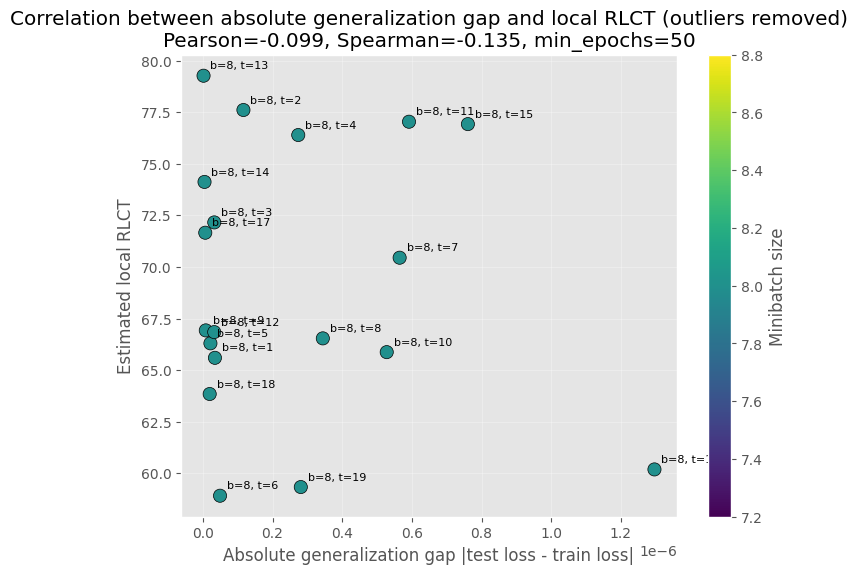

{8: {'mean_generalization_gap': 2.616152285683208e-07,
  'mean_lambda_hat': 69.2623225915866,
  'n_inliers': 19}}

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    filtered_generalization_gaps,
    filtered_lambda_hats,
    c=filtered_batch_labels,
    cmap="viridis",
    s=90,
    edgecolor="black",
    linewidth=0.5,
)

for record in filtered_records:
    ax.annotate(
        f"b={record['minibatch_size']}, t={record['trial']}",
        (record["generalization_gap"], record["lambda_hat"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

ax.set_xlabel("Absolute generalization gap |test loss - train loss|")
ax.set_ylabel("Estimated local RLCT")
ax.set_title(
    "Correlation between absolute generalization gap and local RLCT (outliers removed)\n"
    f"Pearson={filtered_pearson_corr:.3f}, Spearman={filtered_spearman_corr:.3f}, min_epochs={min_epochs}"
)
ax.grid(True, alpha=0.3)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Minibatch size")
plt.show()

summary = {}
for minibatch_size in minibatch_sizes:
    batch_records = [record for record in filtered_records if record["minibatch_size"] == minibatch_size]
    if batch_records:
        summary[minibatch_size] = {
            "mean_generalization_gap": float(np.mean([record["generalization_gap"] for record in batch_records])),
            "mean_lambda_hat": float(np.mean([record["lambda_hat"] for record in batch_records])),
            "n_inliers": len(batch_records),
        }

summary


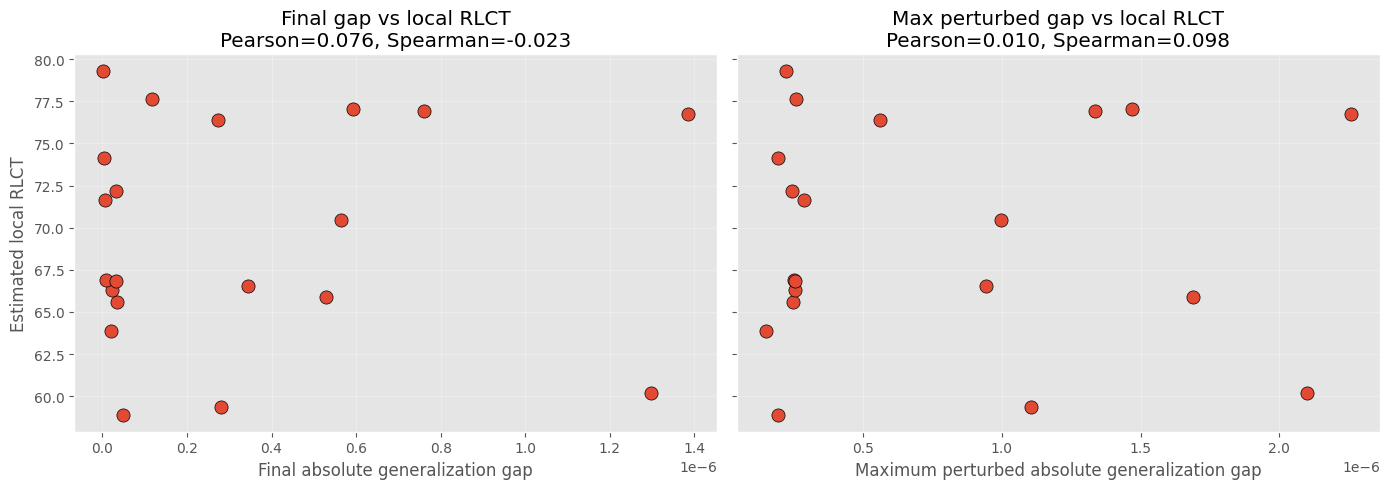

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(generalization_gaps, lambda_hats, s=90, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Final absolute generalization gap")
axes[0].set_ylabel("Estimated local RLCT")
axes[0].set_title(
    "Final gap vs local RLCT\n"
    f"Pearson={pearson_corr:.3f}, Spearman={spearman_corr:.3f}"
)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(max_perturbed_generalization_gaps, lambda_hats, s=90, edgecolor="black", linewidth=0.5)
axes[1].set_xlabel("Maximum perturbed absolute generalization gap")
axes[1].set_title(
    "Max perturbed gap vs local RLCT\n"
    f"Pearson={max_gap_pearson_corr:.3f}, Spearman={max_gap_spearman_corr:.3f}"
)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
